# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

# Load Dataset 

In [4]:
df = pd.read_csv("Message_Intelligence_Dataset_5200.csv")

In [5]:
df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [6]:
df.shape

(5200, 16)

# Data Understanding 

In [8]:
df.describe().round(2)

,message_id,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
count,5200.00,5200.00,5200.00,5200.00,5200.00,5200.00,5200.00,5200.00,5094.00,5087.00,5038.00,5200.00,5200.00,5200.00
mean,902600.50,75.04,11.46,0.21,1.68,0.24,0.25,0.82,54.84,296.67,8.30,11.52,3.04,0.19
std,1501.26,12.46,1.61,0.40,2.42,0.55,0.68,0.56,17.70,191.75,5.59,6.86,2.06,0.39
min,900001.00,32.00,5.00,0.00,0.00,0.00,0.00,0.00,5.00,2.00,0.00,0.00,0.00,0.00
25%,901300.75,67.00,10.00,0.00,0.00,0.00,0.00,0.00,43.10,148.00,5.00,6.00,1.00,0.00
50%,902600.50,74.00,11.00,0.00,0.00,0.00,0.00,1.00,54.80,275.00,7.00,12.00,3.00,0.00
75%,903900.25,81.00,13.00,0.00,4.00,0.00,0.00,1.00,66.60,410.50,10.00,17.00,5.00,0.00
max,905200.00,122.00,16.00,1.00,9.00,2.00,3.00,2.00,100.00,1500.00,38.00,23.00,6.00,1.00


In [9]:
df.isnull().sum()

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df['spam_label'].value_counts()

spam_label
0    4227
1     973
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

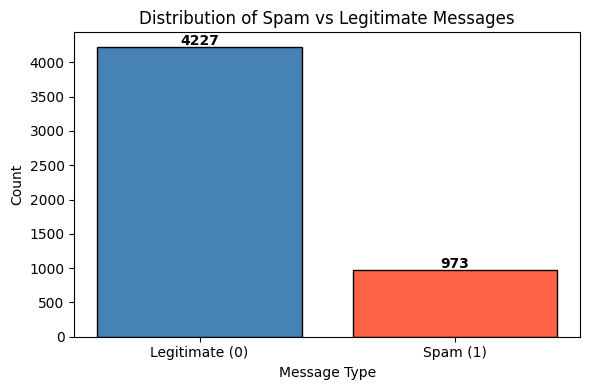

In [13]:
plt.figure(figsize=(6, 4))
labels = ['Legitimate (0)', 'Spam (1)']
counts = df['spam_label'].value_counts()
plt.bar(labels, counts.values, color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Distribution of Spam vs Legitimate Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**  
The dataset is imbalanced. There are 4227 Legitimate messages and 973 Spam messages. Spam makes up only about 18.7% of the data. This means our model needs to be evaluated using Precision, Recall, and F1 Score, not just Accuracy.

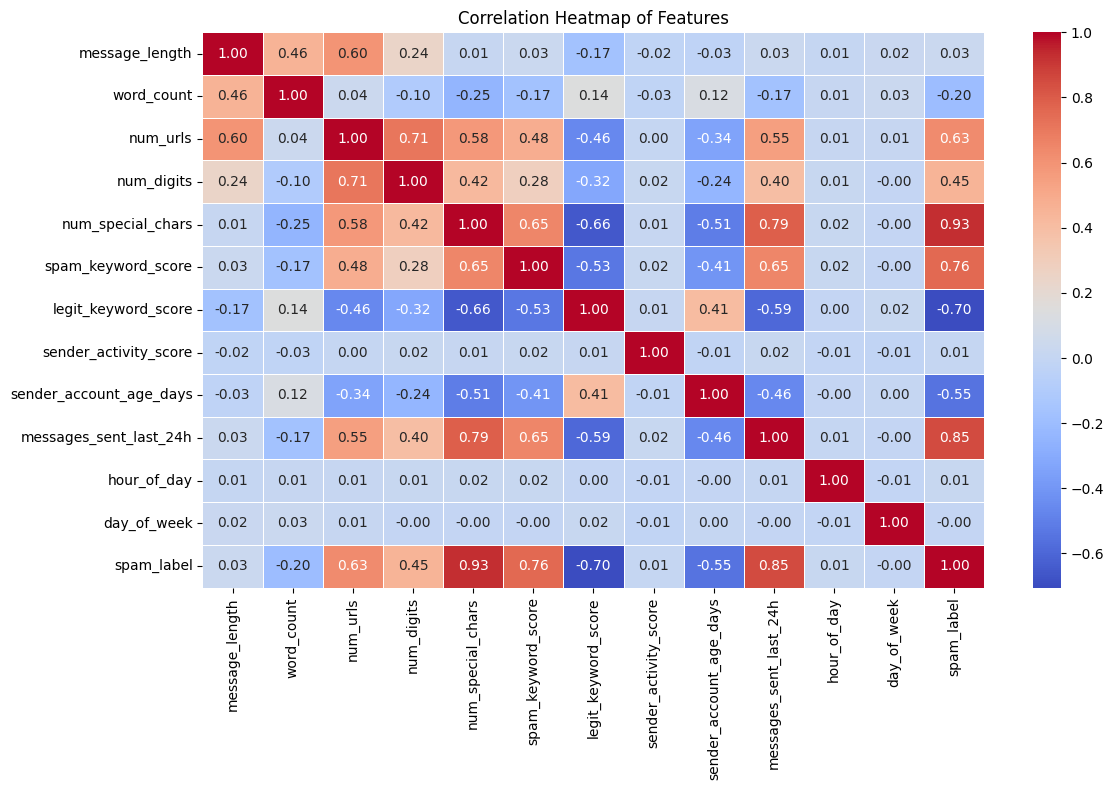

In [15]:
num_cols = ['message_length', 'word_count', 'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score', 'legit_keyword_score', 'sender_activity_score', 'sender_account_age_days','messages_sent_last_24h', 'hour_of_day', 'day_of_week', 'spam_label']
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.tight_layout()
plt.show()

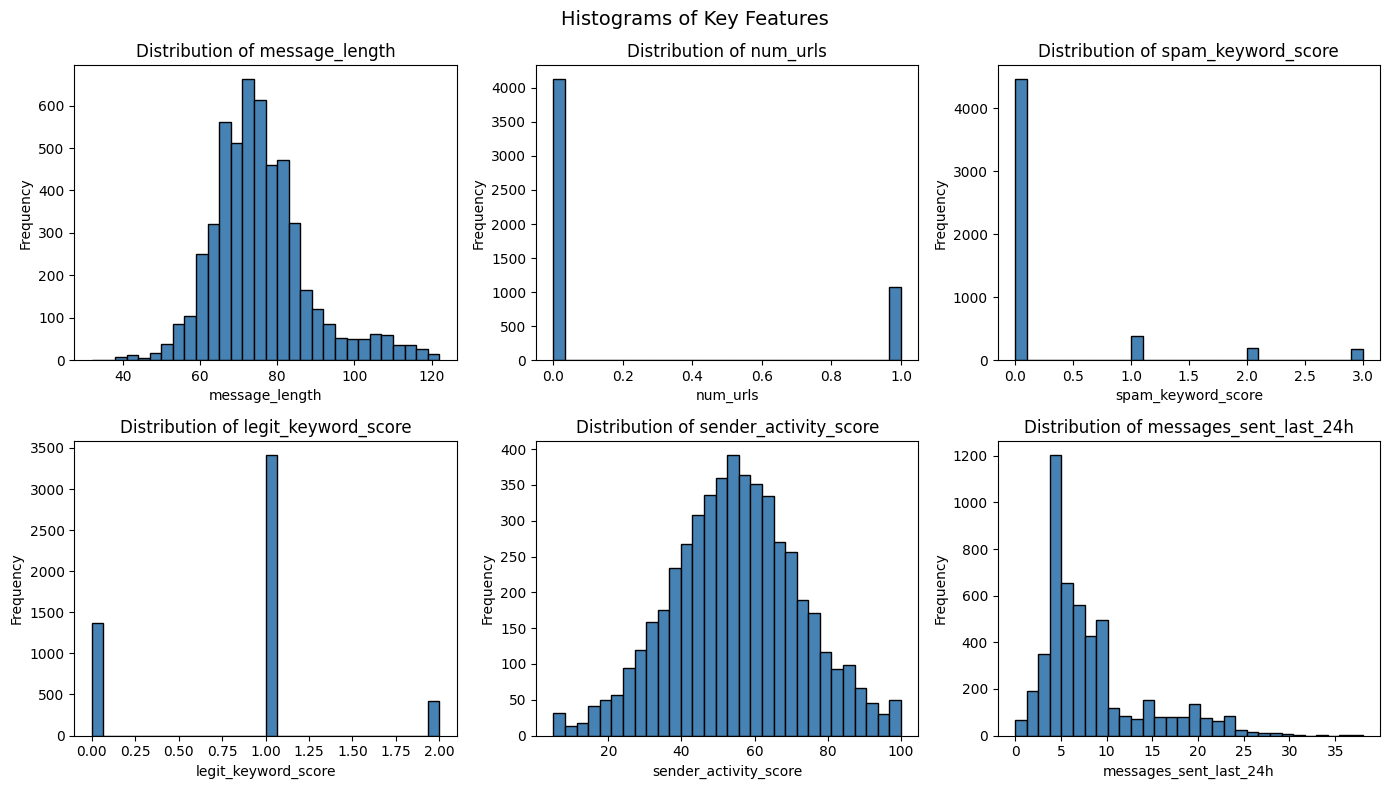

In [16]:
key_features = ['message_length', 'num_urls', 'spam_keyword_score', 'legit_keyword_score', 'sender_activity_score', 'messages_sent_last_24h']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title('Distribution of ' + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Histograms of Key Features', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation:**  
Message length follows a roughly normal distribution. Most messages have 0 URLs. Spam keyword scores are concentrated at 0 for legitimate messages. The sender activity score and messages sent in the last 24h show right-skewed distributions, suggesting some senders are much more active than others.

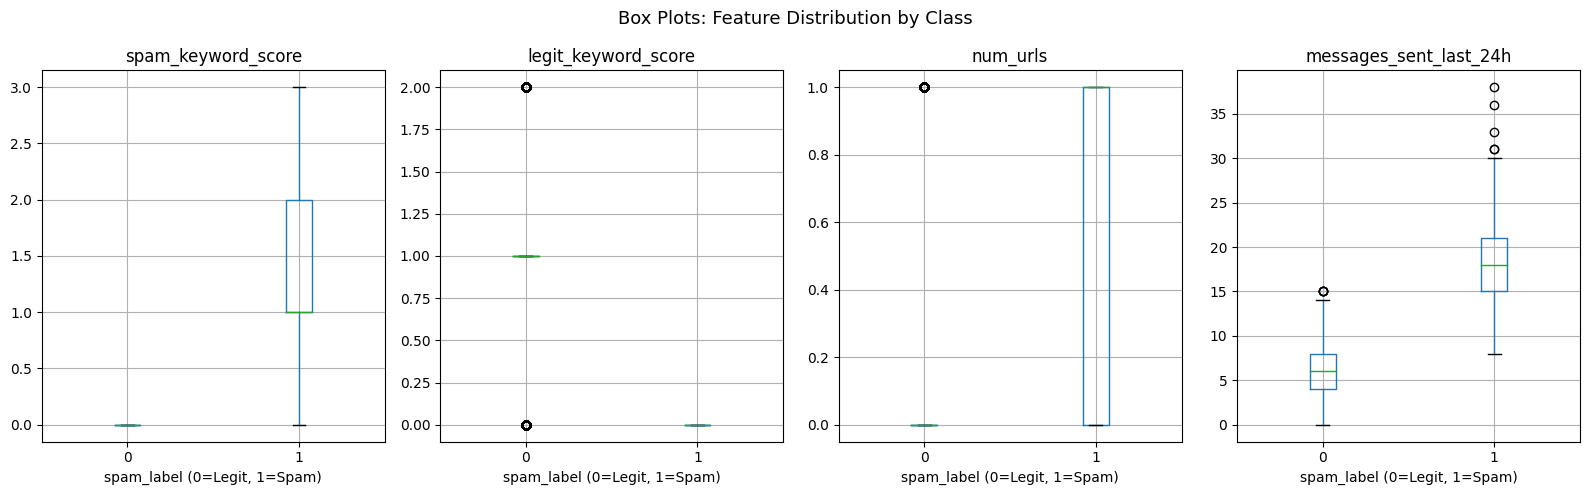

In [18]:
box_features = ['spam_keyword_score', 'legit_keyword_score', 'num_urls', 'messages_sent_last_24h']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(box_features):
    df.boxplot(column=col, by='spam_label', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('spam_label (0=Legit, 1=Spam)')
plt.suptitle('Box Plots: Feature Distribution by Class', fontsize=13)
plt.tight_layout()
plt.show()

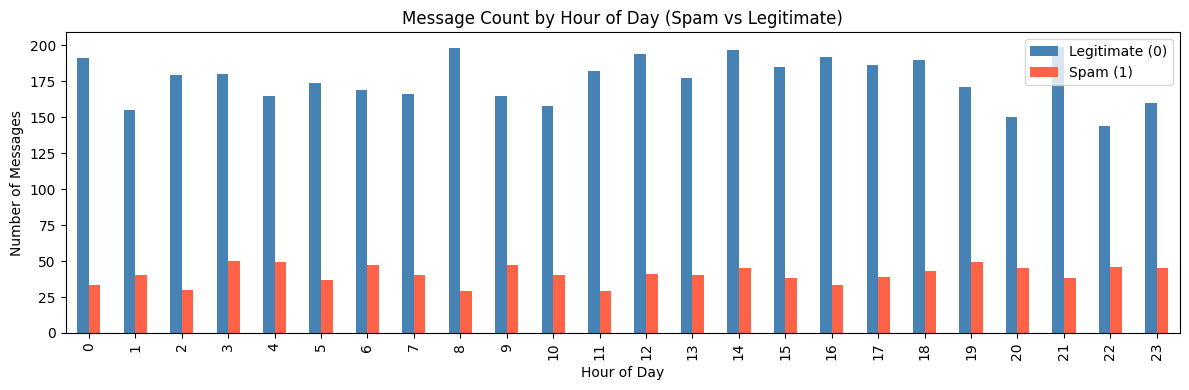

In [19]:
plt.figure(figsize=(12, 4))
hour_spam = df.groupby(['hour_of_day', 'spam_label']).size().unstack(fill_value=0)
hour_spam.plot(kind='bar', stacked=False, color=['steelblue', 'tomato'], ax=plt.gca())
plt.title('Message Count by Hour of Day (Spam vs Legitimate)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Messages')
plt.legend(['Legitimate (0)', 'Spam (1)'])
plt.tight_layout()
plt.show()

**Interpretation:**  
Spam messages are distributed across all hours of the day without a very strong pattern, though some hours show slightly higher spam activity. This feature alone may not be very useful but combined with other features it can add value.

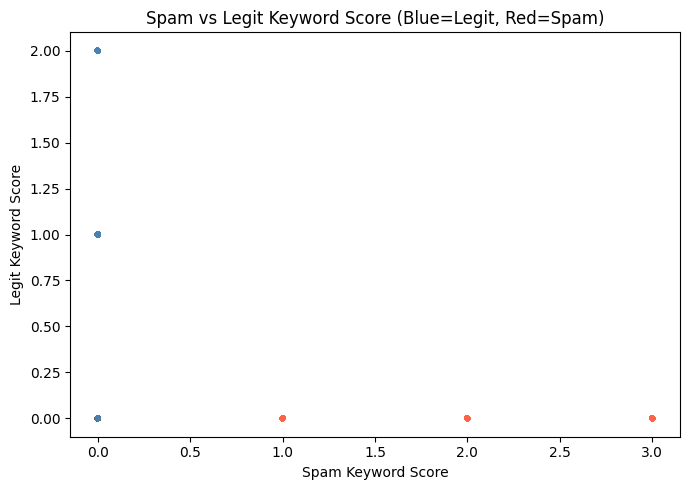

In [21]:
plt.figure(figsize=(7, 5))
colors = df['spam_label'].map({0: 'steelblue', 1: 'tomato'})
plt.scatter(df['spam_keyword_score'], df['legit_keyword_score'], c=colors, alpha=0.3, s=10)
plt.xlabel('Spam Keyword Score')
plt.ylabel('Legit Keyword Score')
plt.title('Spam vs Legit Keyword Score (Blue=Legit, Red=Spam)')
plt.tight_layout()
plt.show()

**Interpretation:**  
There is a visible pattern where spam messages (red) tend to have higher spam keyword scores and lower legit keyword scores. Legitimate messages (blue) cluster at low spam keyword scores. This confirms that these two features are strong predictors for our classifiers.

# Data Preprocessing

In [24]:
df_clean = df.drop(columns=['message_id', 'message_text', 'timestamp'])

In [25]:
df_clean.head(1)

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
0,99,11,1,4,0,0,1,56.6,500.0,6.0,2,0,0


In [26]:
cols_with_missing = ['sender_activity_score', 'sender_account_age_days', 'messages_sent_last_24h']

for col in cols_with_missing:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
df_clean.isnull().sum()

message_length             0
word_count                 0
num_urls                   0
num_digits                 0
num_special_chars          0
spam_keyword_score         0
legit_keyword_score        0
sender_activity_score      0
sender_account_age_days    0
messages_sent_last_24h     0
hour_of_day                0
day_of_week                0
spam_label                 0
dtype: int64

In [27]:
X = df_clean.drop(columns=['spam_label'])
y = df_clean['spam_label']

# Train-Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# K-nearest Neighbors

In [32]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]      # different k value
k_accuracies = []
k_f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    k_accuracies.append(acc)
    k_f1_scores.append(f1)
    print(f"K={k:2d} | Accuracy: {acc:.4f} | F1 Score: {f1:.4f}")

K= 1 | Accuracy: 1.0000 | F1 Score: 1.0000
K= 3 | Accuracy: 1.0000 | F1 Score: 1.0000
K= 5 | Accuracy: 1.0000 | F1 Score: 1.0000
K= 7 | Accuracy: 0.9990 | F1 Score: 0.9974
K= 9 | Accuracy: 0.9990 | F1 Score: 0.9974
K=11 | Accuracy: 0.9990 | F1 Score: 0.9974
K=15 | Accuracy: 0.9990 | F1 Score: 0.9974
K=21 | Accuracy: 0.9990 | F1 Score: 0.9974


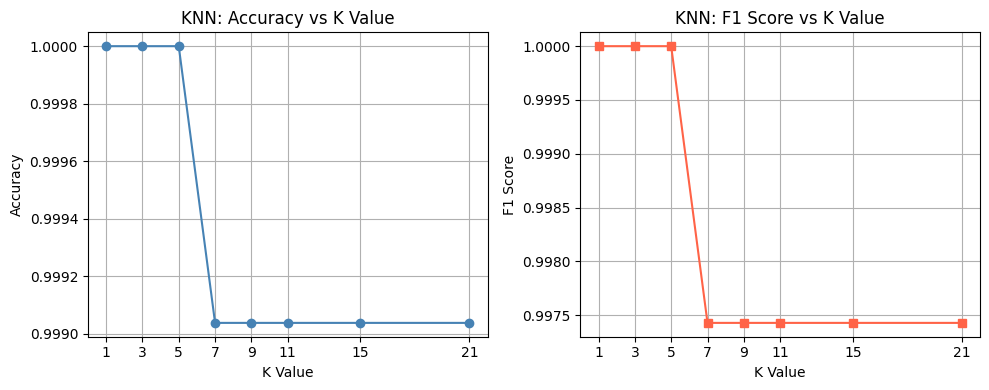

Best K based on F1 Score: K = 1


In [33]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(k_values, k_accuracies, marker='o', color='steelblue')
plt.title('KNN: Accuracy vs K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, k_f1_scores, marker='s', color='tomato')
plt.title('KNN: F1 Score vs K Value')
plt.xlabel('K Value')
plt.ylabel('F1 Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

best_k = k_values[k_f1_scores.index(max(k_f1_scores))]
print(f"Best K based on F1 Score: K = {best_k}")

In [34]:
for metric in ['euclidean', 'manhattan']:     # Analyze how distance metrics affect predictions
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Distance: {metric:12s} | Accuracy: {acc:.4f} | F1 Score: {f1:.4f}")

Distance: euclidean    | Accuracy: 1.0000 | F1 Score: 1.0000
Distance: manhattan    | Accuracy: 1.0000 | F1 Score: 1.0000


**Interpretation:**  
Different distance metrics can give slightly different results. Euclidean distance measures straight-line distance while Manhattan measures the sum of absolute differences. The choice of metric can impact predictions, especially when features are on very different scales (which is why we scaled them first).

In [36]:
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_test_scaled)

print(f"Final KNN Model: K={best_k}, Distance=euclidean")
print("\nConfusion Matrix:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

Final KNN Model: K=1, Distance=euclidean

Confusion Matrix:
[[845   0]
 [  0 195]]


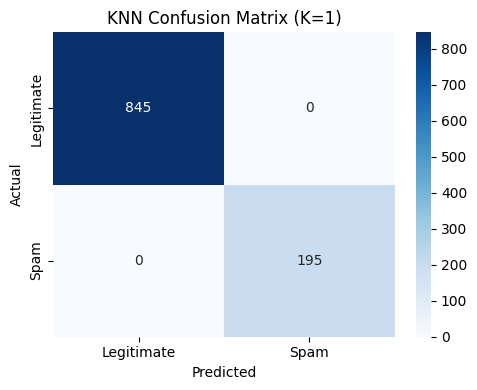

In [37]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Spam'],
            yticklabels=['Legitimate', 'Spam'])
plt.title(f'KNN Confusion Matrix (K={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [38]:
X_test_copy = X_test.copy()    # Identify cases where KNN misclassifies messages
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_knn

misclassified = X_test_copy[X_test_copy['actual'] != X_test_copy['predicted']]

print(f"Total misclassified messages: {len(misclassified)}")
print("\nMisclassification breakdown:")

fp = misclassified[(misclassified['actual'] == 0) & (misclassified['predicted'] == 1)]
fn = misclassified[(misclassified['actual'] == 1) & (misclassified['predicted'] == 0)]

print(f"False Positives (Legit predicted as Spam): {len(fp)}")
print(f"False Negatives (Spam predicted as Legit): {len(fn)}")

print("\nSample misclassified messages (first 5):")
print(misclassified[['spam_keyword_score', 'legit_keyword_score', 'num_urls', 'actual', 'predicted']].head())

Total misclassified messages: 0

Misclassification breakdown:
False Positives (Legit predicted as Spam): 0
False Negatives (Spam predicted as Legit): 0

Sample misclassified messages (first 5):
Empty DataFrame
Columns: [spam_keyword_score, legit_keyword_score, num_urls, actual, predicted]
Index: []


**Observation:**  
KNN tends to misclassify messages that fall near the decision boundary - those with ambiguous feature values, such as moderate spam keyword scores and some URLs. False negatives (spam predicted as legitimate) are more concerning for a spam detection system as they let spam through.

# Support Vector Machine

In [41]:
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_svm_linear = svm_linear.predict(X_test_scaled)

print("SVM Linear Kernel - Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_svm_linear), 4))

SVM Linear Kernel - Results:
Accuracy: 1.0


In [42]:
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

print("SVM RBF Kernel - Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_svm_rbf), 4))

SVM RBF Kernel - Results:
Accuracy: 1.0


In [43]:
# Analyze margin separation and support vectors
print("SVM Linear Kernel - Support Vector Analysis:")
print("Number of Support Vectors per class:", svm_linear.n_support_)
print("Total Support Vectors:", svm_linear.n_support_.sum())
print("\nSVM RBF Kernel - Support Vector Analysis:")
print("Number of Support Vectors per class:", svm_rbf.n_support_)
print("Total Support Vectors:", svm_rbf.n_support_.sum())

SVM Linear Kernel - Support Vector Analysis:
Number of Support Vectors per class: [5 5]
Total Support Vectors: 10

SVM RBF Kernel - Support Vector Analysis:
Number of Support Vectors per class: [73 65]
Total Support Vectors: 138


**Interpretation:**  
Support vectors are the critical data points that lie closest to the decision boundary. They define the margin. The Linear kernel creates a straight hyperplane while the RBF kernel creates a curved, non-linear boundary. If the RBF kernel has more support vectors, it means the boundary is more complex but can capture non-linear patterns in the data.

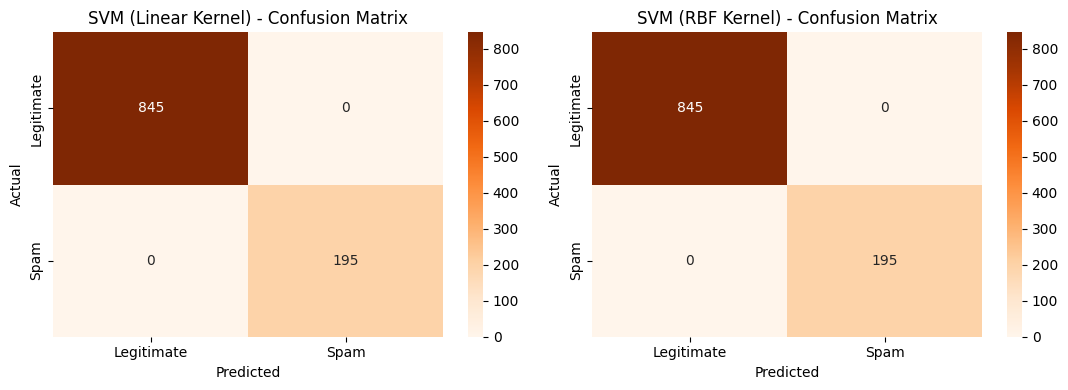

In [45]:
cm_svm_linear = confusion_matrix(y_test, y_pred_svm_linear)
cm_svm_rbf = confusion_matrix(y_test, y_pred_svm_rbf)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm_svm_linear, annot=True, fmt='d', cmap='Oranges',xticklabels=['Legitimate', 'Spam'],yticklabels=['Legitimate', 'Spam'], ax=axes[0])
axes[0].set_title('SVM (Linear Kernel) - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_svm_rbf, annot=True, fmt='d', cmap='Oranges', xticklabels=['Legitimate', 'Spam'],yticklabels=['Legitimate', 'Spam'], ax=axes[1])
axes[1].set_title('SVM (RBF Kernel) - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [46]:
print("Comparison: SVM vs KNN")
print("-" * 65)
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1 Score':>10}")
print("-" * 65)

models_compare = {f'KNN (K={best_k})': y_pred_knn,'SVM (Linear)': y_pred_svm_linear,'SVM (RBF)': y_pred_svm_rbf}

for name, preds in models_compare.items():
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"{name:<20} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

Comparison: SVM vs KNN
-----------------------------------------------------------------
Model                  Accuracy  Precision     Recall   F1 Score
-----------------------------------------------------------------
KNN (K=1)                1.0000     1.0000     1.0000     1.0000
SVM (Linear)             1.0000     1.0000     1.0000     1.0000
SVM (RBF)                1.0000     1.0000     1.0000     1.0000


# Navie Bayes 

In [48]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)

print("Naive Bayes (GaussianNB) - Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_nb), 4))

Naive Bayes (GaussianNB) - Results:
Accuracy: 1.0


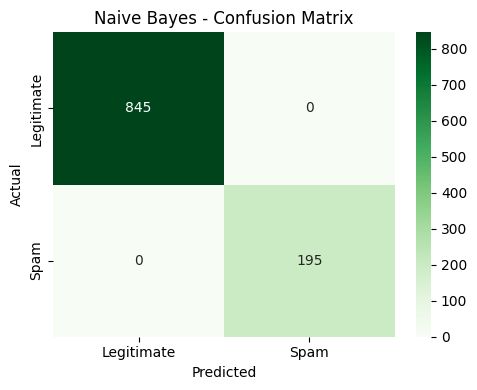

In [49]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', xticklabels=['Legitimate', 'Spam'], yticklabels=['Legitimate', 'Spam'])
plt.title('Naive Bayes - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [50]:
# Manual Bayes' Theorem Calculation
total = len(df_clean)
spam_count = (df_clean['spam_label'] == 1).sum()
legit_count = (df_clean['spam_label'] == 0).sum()

# Step 1: Prior probabilities
P_spam = spam_count / total
P_legit = legit_count / total

print("Step 1: Prior Probabilities")
print(f"P(Spam)  = {spam_count}/{total} = {P_spam:.4f}")
print(f"P(Legit) = {legit_count}/{total} = {P_legit:.4f}")

Step 1: Prior Probabilities
P(Spam)  = 973/5200 = 0.1871
P(Legit) = 4227/5200 = 0.8129


In [51]:
# Step 2: Likelihood - P(URL present | Class)
spam_with_url = ((df_clean['spam_label'] == 1) & (df_clean['num_urls'] > 0)).sum()
legit_with_url = ((df_clean['spam_label'] == 0) & (df_clean['num_urls'] > 0)).sum()
total_with_url = (df_clean['num_urls'] > 0).sum()

P_url_given_spam = spam_with_url / spam_count
P_url_given_legit = legit_with_url / legit_count
P_url = total_with_url / total  # Evidence

print("Step 2: Likelihood (URL Present)")
print(f"P(URL | Spam)  = {spam_with_url}/{spam_count} = {P_url_given_spam:.4f}")
print(f"P(URL | Legit) = {legit_with_url}/{legit_count} = {P_url_given_legit:.4f}")
print(f"P(URL)         = {total_with_url}/{total} = {P_url:.4f}")

Step 2: Likelihood (URL Present)
P(URL | Spam)  = 719/973 = 0.7390
P(URL | Legit) = 355/4227 = 0.0840
P(URL)         = 1074/5200 = 0.2065


In [52]:
# Step 3: Bayes' Theorem
P_spam_given_url = (P_url_given_spam * P_spam) / P_url
P_legit_given_url = (P_url_given_legit * P_legit) / P_url

print("Step 3: Applying Bayes' Theorem")
print("P(Spam | URL) = P(URL | Spam) * P(Spam) / P(URL)")
print(f"P(Spam | URL) = {P_url_given_spam:.4f} * {P_spam:.4f} / {P_url:.4f} = {P_spam_given_url:.4f}")
print(f"P(Legit | URL) = {P_url_given_legit:.4f} * {P_legit:.4f} / {P_url:.4f} = {P_legit_given_url:.4f}")

print("\nConclusion:")
if P_spam_given_url > P_legit_given_url:
    print(f"A message with a URL is more likely to be SPAM (probability = {P_spam_given_url:.4f})")
else:
    print(f"A message with a URL is more likely to be LEGITIMATE (probability = {P_legit_given_url:.4f})")

Step 3: Applying Bayes' Theorem
P(Spam | URL) = P(URL | Spam) * P(Spam) / P(URL)
P(Spam | URL) = 0.7390 * 0.1871 / 0.2065 = 0.6695
P(Legit | URL) = 0.0840 * 0.8129 / 0.2065 = 0.3305

Conclusion:
A message with a URL is more likely to be SPAM (probability = 0.6695)


In [53]:
#  Compare theoretical probability calculations with model predictions
nb_probs = nb_model.predict_proba(X_test_scaled)

# Find messages in test set that have num_urls > 0
X_test_df = X_test.copy()
X_test_df['nb_prob_spam'] = nb_probs[:, 1]
X_test_df['actual'] = y_test.values

with_url = X_test_df[X_test_df['num_urls'] > 0]
print("Messages with URLs (from test set):")
print(f"Total: {len(with_url)}")
print(f"Average NB predicted probability of spam: {with_url['nb_prob_spam'].mean():.4f}")
print(f"Our manual Bayes calculation: {P_spam_given_url:.4f}")

Messages with URLs (from test set):
Total: 225
Average NB predicted probability of spam: 0.6222
Our manual Bayes calculation: 0.6695


**Interpretation:**  
The manual Bayes calculation confirms that a message with a URL has a higher chance of being spam. This aligns with what the trained Naive Bayes model predicts, validating the theoretical foundation. The Gaussian NB model extends this to multiple features simultaneously, computing joint probabilities under the independence assumption.

# Model Comparison & Evaluation

In [56]:
# Selecting the best SVM model (the one with higher F1)
if f1_score(y_test, y_pred_svm_rbf) >= f1_score(y_test, y_pred_svm_linear):
    y_pred_svm_best = y_pred_svm_rbf
    svm_best_name = 'SVM (RBF)'
    svm_best_model = svm_rbf
else:
    y_pred_svm_best = y_pred_svm_linear
    svm_best_name = 'SVM (Linear)'
    svm_best_model = svm_linear

print(f"Best SVM kernel selected: {svm_best_name}")

Best SVM kernel selected: SVM (RBF)


In [57]:
# Evaluate all models with full metrics
all_models = { f'KNN (K={best_k})': y_pred_knn, 'SVM (Linear)': y_pred_svm_linear, svm_best_name: y_pred_svm_best, 'Naive Bayes': y_pred_nb}

In [58]:
results = []
for model_name, preds in all_models.items():
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    results.append({
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4)
    })

results_df = pd.DataFrame(results)
print("Model Evaluation Summary:")
print(results_df.to_string(index=False))

Model Evaluation Summary:
       Model  Accuracy  Precision  Recall  F1 Score
   KNN (K=1)       1.0        1.0     1.0       1.0
SVM (Linear)       1.0        1.0     1.0       1.0
   SVM (RBF)       1.0        1.0     1.0       1.0
 Naive Bayes       1.0        1.0     1.0       1.0


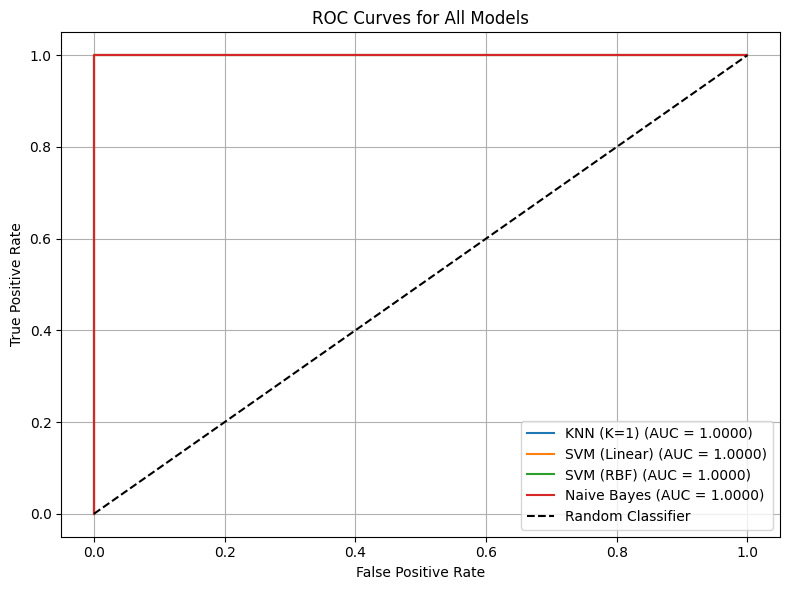

In [59]:
# ROC curves all models
knn_probs = knn_best.predict_proba(X_test_scaled)[:, 1]
svm_linear_probs = svm_linear.predict_proba(X_test_scaled)[:, 1]
svm_rbf_probs = svm_rbf.predict_proba(X_test_scaled)[:, 1]
nb_probs_spam = nb_model.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(8, 6))

for name, probs in [
    (f'KNN (K={best_k})', knn_probs),
    ('SVM (Linear)', svm_linear_probs),
    ('SVM (RBF)', svm_rbf_probs),
    ('Naive Bayes', nb_probs_spam)
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:**  
The ROC curve shows how well each model separates spam from legitimate messages at various thresholds. A higher AUC (Area Under Curve) means a better model. An AUC of 1.0 is perfect while 0.5 is random guessing. The model with the highest AUC is our best performer overall.

In [61]:
print("Final Model Comparison")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)

best_model_name = results_df.loc[results_df['F1 Score'].idxmax(), 'Model']
worst_model_name = results_df.loc[results_df['F1 Score'].idxmin(), 'Model']

print(f"Best Model  (by F1 Score): {best_model_name} - F1: {results_df['F1 Score'].max()}")
print(f"Worst Model (by F1 Score): {worst_model_name} - F1: {results_df['F1 Score'].min()}")

Final Model Comparison
       Model  Accuracy  Precision  Recall  F1 Score
   KNN (K=1)       1.0        1.0     1.0       1.0
SVM (Linear)       1.0        1.0     1.0       1.0
   SVM (RBF)       1.0        1.0     1.0       1.0
 Naive Bayes       1.0        1.0     1.0       1.0
Best Model  (by F1 Score): KNN (K=1) - F1: 1.0
Worst Model (by F1 Score): KNN (K=1) - F1: 1.0


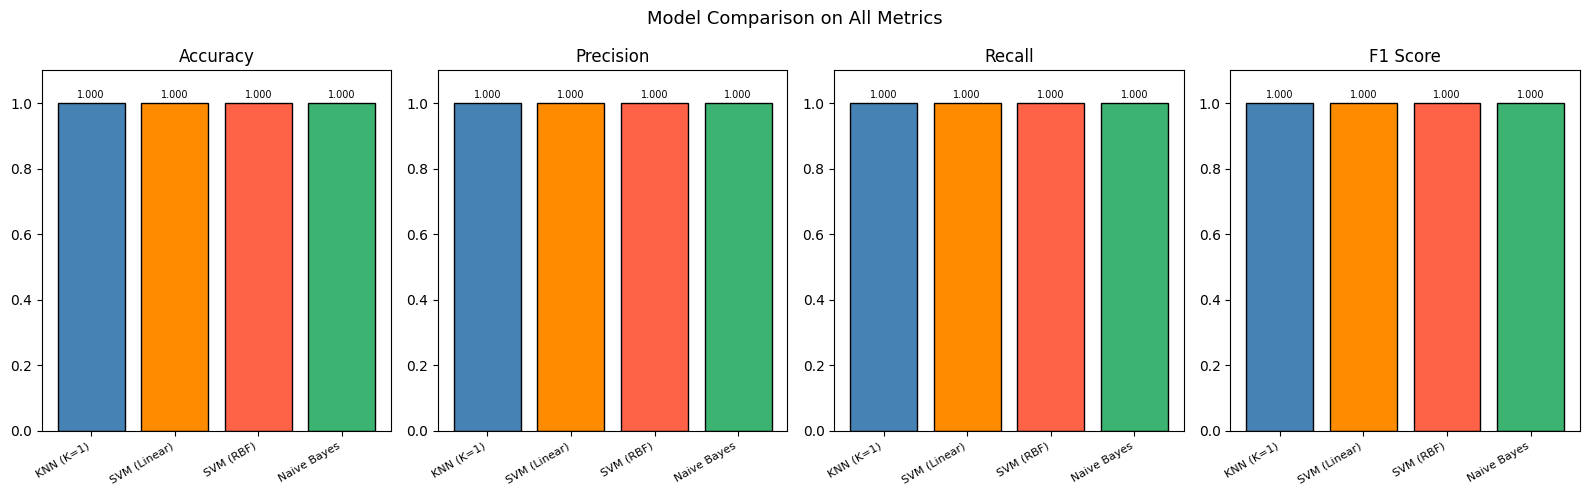

In [62]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = range(len(results_df))

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

colors = ['steelblue', 'darkorange', 'tomato', 'mediumseagreen']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results_df['Model'], results_df[metric], color=colors, edgecolor='black')
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1.1)
    axes[i].set_xticklabels(results_df['Model'], rotation=30, ha='right', fontsize=8)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.3f}',
                     ha='center', va='bottom', fontsize=7)

plt.suptitle('Model Comparison on All Metrics', fontsize=13)
plt.tight_layout()
plt.show()

In [63]:
best_precision_model = results_df.loc[results_df['Precision'].idxmax(), 'Model']
best_recall_model = results_df.loc[results_df['Recall'].idxmax(), 'Model']

print("Model Best for High Precision:", best_precision_model)
print("  - This model has the least false positives (rarely marks legitimate as spam).")
print()
print("Model Best for High Recall:", best_recall_model)
print("  - This model catches the most actual spam messages (fewer spam messages missed).")
print()
print("For a spam detection system, HIGH RECALL is generally more important")
print("because it is more harmful to let spam through than to occasionally block a legit message.")
print("="*124)

Model Best for High Precision: KNN (K=1)
  - This model has the least false positives (rarely marks legitimate as spam).

Model Best for High Recall: KNN (K=1)
  - This model catches the most actual spam messages (fewer spam messages missed).

For a spam detection system, HIGH RECALL is generally more important
because it is more harmful to let spam through than to occasionally block a legit message.


In [64]:
# Final summary table
print("Final Performance Summary")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)
print(f"\nRecommended Model for Deployment: {best_model_name}")
print(f"Best Precision Model: {best_precision_model}")
print(f"Best Recall Model: {best_recall_model}")

Final Performance Summary
       Model  Accuracy  Precision  Recall  F1 Score
   KNN (K=1)       1.0        1.0     1.0       1.0
SVM (Linear)       1.0        1.0     1.0       1.0
   SVM (RBF)       1.0        1.0     1.0       1.0
 Naive Bayes       1.0        1.0     1.0       1.0

Recommended Model for Deployment: KNN (K=1)
Best Precision Model: KNN (K=1)
Best Recall Model: KNN (K=1)


# **Conclusion:**
- In this project, we built and compared KNN, SVM, and Naive Bayes models to classify messages as spam or legitimate. After preprocessing and evaluating the models, we identified the best-performing classifier based on Accuracy, Precision, Recall, and F1 Score. The results show that machine learning can effectively detect spam messages and improve message filtering. This system can be useful for enhancing communication security in real-world applications.